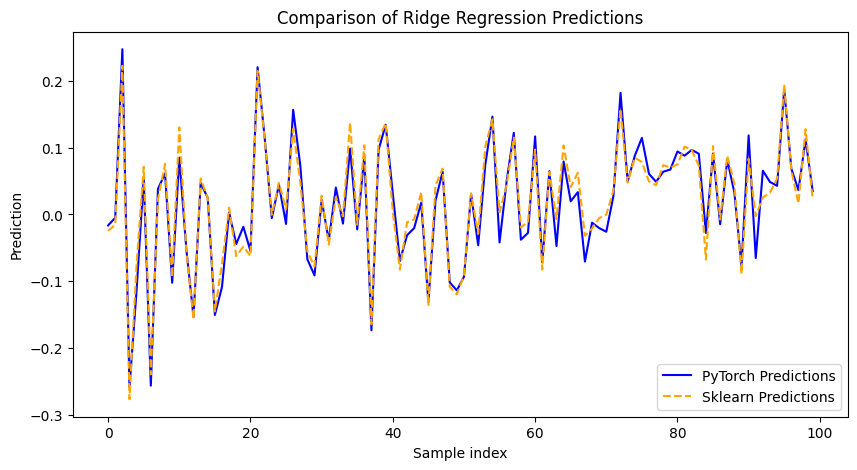

In [17]:
import torch
import torch.optim as optim
from sklearn.linear_model import Ridge as SklearnRidge
import matplotlib.pyplot as plt
import numpy as np

class Ridge:
    def __init__(self, alpha=1.0, fit_intercept=True, batch_size=32, device='cpu'):
        self.alpha = alpha
        self.fit_intercept = fit_intercept
        self.batch_size = batch_size
        self.device = device
        self.w = None
        self.b = None

    def fit(self, X, y, epochs=1000, lr=0.01):
        n_samples, n_features = X.shape
        self.w = torch.randn(n_features, 1, requires_grad=True, device=self.device)
        if self.fit_intercept:
            self.b = torch.randn(1, requires_grad=True, device=self.device)

        optimizer = optim.SGD([self.w] + ([self.b] if self.fit_intercept else []), lr=lr)

        for epoch in range(epochs):
            for i in range(0, n_samples, self.batch_size):
                X_batch = X[i:i + self.batch_size]
                y_batch = y[i:i + self.batch_size]
                predictions = self.model(X_batch)
                loss = self.loss(predictions, y_batch)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

    def model(self, x):
        return x @ self.w + (self.b if self.fit_intercept else 0)

    def loss(self, predictions, y):
        mse_loss = torch.mean((predictions - y) ** 2)
        ridge_penalty = self.alpha * torch.sum(self.w ** 2)
        return mse_loss + ridge_penalty

    def predict(self, X):
        return self.model(X).detach().cpu().numpy()

if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # Generate synthetic data
    X_torch = torch.randn(13000, 100).to(device)
    y_torch = torch.randn(13000, 1).to(device)

    # PyTorch Ridge Model
    torch_ridge = Ridge(alpha=1e-3, fit_intercept=True, device=device)
    torch_ridge.fit(X_torch, y_torch, epochs=300, lr=0.001)
    torch_predictions = torch_ridge.predict(X_torch)

    # Sklearn Ridge Model
    X_sklearn = X_torch.cpu().numpy()
    y_sklearn = y_torch.cpu().numpy().ravel()
    sklearn_ridge = SklearnRidge(alpha=1e-3, fit_intercept=True)
    sklearn_ridge.fit(X_sklearn, y_sklearn)
    sklearn_predictions = sklearn_ridge.predict(X_sklearn)

    # Plotting results
    plt.figure(figsize=(10, 5))
    plt.plot(torch_predictions[:100], label="PyTorch Predictions", color="blue")
    plt.plot(sklearn_predictions[:100], label="Sklearn Predictions", color="orange", linestyle="dashed")
    plt.xlabel("Sample index")
    plt.ylabel("Prediction")
    plt.title("Comparison of Ridge Regression Predictions")
    plt.legend()
    plt.show()
